# N=5 open chain: paper training figures

Editable notebook version of the training-figure code in `code/make_figs.py`.
Run the cells from top to bottom to reproduce `figs/chain_N5/` for **AM and AM2**, the base initial point and smooth schedule.

The actual plotting code is included below, rather than invoking the command-line plotting script. Only the shared style is loaded from `code/figstyle.py`. Inputs are the existing files in `data/train/` and `data/phase/`; no training, remote jobs, or data downloads are performed.

By default, running the notebook **replaces the corresponding PDFs/PNGs** in the geometry folder and displays each figure inline. Set `SAVE_FIGURES = False` in the setup cell to preview only. Section 3c additionally reproduces the top-level `trajectory_combo_chain_N5.pdf`: both its ⟨AFM²⟩ background **and** its overlaid trajectories are AFM², the latter from the high-learning-rate (`lr=0.1`) runs. The separate gradient-bias figure is not part of this notebook.


## Setup and figure style


In [1]:
from pathlib import Path
import os
import re
import glob
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# Locate paper_figs when launched from this folder, AFM_searching, or the repo.
candidates = []
for parent in (Path.cwd(), *Path.cwd().parents):
    candidates.extend((parent, parent / "paper_figs", parent / "AFM_searching" / "paper_figs"))
PAPER = next((p for p in candidates
              if (p / "code" / "figstyle.py").is_file()
              and (p / "data" / "train").is_dir()), None)
if PAPER is None:
    raise FileNotFoundError("Open this notebook from inside the QEP_sparse checkout.")

DATA = str(PAPER / "data")
# Optional environment override is useful for checking plots without replacing originals.
FIGS = str(Path(os.environ.get("AFM_NOTEBOOK_FIGURE_ROOT", str(PAPER / "figs"))))
SAVE_FIGURES = True  # False: display figures inline without writing PDFs/PNGs.

spec = importlib.util.spec_from_file_location("afm_paper_figstyle", PAPER / "code" / "figstyle.py")
F = importlib.util.module_from_spec(spec)
spec.loader.exec_module(F)
F.use_style()

GEOMETRY = "chain_N5"
COSTS = ("AM", "AM2")
INIT = "base"
SCHEDULE = "smooth"

TL_DEFAULT = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
COST_LABEL = {"AM": r"$\langle \mathrm{AM}\rangle$",
              "AM2": r"$\langle \mathrm{AM}^2\rangle$"}
START = (1.0, 2.6)          # (Omega_0, Delta_0) shared by every base run

# The study reports two estimators: exact QEP and QEP with adiabatic state
# preparation.  The cached variant was also run (its data is in data/train) but
# is out of scope here, so it is not plotted.
METHODS = ("ED", "AE")


def pretty(tag):
    m = re.match(r"chain_N(\d+)$", tag)
    if m:
        return f"$N={m.group(1)}$ open chain"
    m = re.match(r"lattice_(\d+)x(\d+)$", tag)
    if m:
        return f"${m.group(1)}\\times{m.group(2)}$ open lattice"
    return tag.replace("_", " ")


def save(fig, path):
    """Display the editable plot, optionally writing the usual PDF and PNG."""
    if SAVE_FIGURES:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path)
        fig.savefig(str(Path(path).with_suffix(".png")), dpi=170)
        print("wrote", Path(path).relative_to(Path(FIGS)))
    display(fig)
    plt.close(fig)

print("Data:", DATA)
print("Figures:", Path(FIGS) / GEOMETRY)


Data: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/data
Figures: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/figs/chain_N5


## Load the existing training runs

These helpers and the T grid preserve the original plotting conventions. The data are loaded into memory so files are not left open. Changing plotting settings does not modify the training arrays.


In [2]:
def load_runs(geom_tag, cost, init="base", schedule="smooth"):
    """Return ``{method: {T: npz}}`` for one geometry / cost operator / start."""
    out = {}
    pat = os.path.join(DATA, "train",
                       f"{geom_tag}_{cost}_*_{schedule}_T*_{init}.npz")
    for p in sorted(glob.glob(pat)):
        m = re.match(rf"{re.escape(geom_tag)}_{cost}_(\w+?)_{schedule}_T(.+)_{init}\.npz",
                     os.path.basename(p))
        if not m:
            continue
        method, T = m.group(1), m.group(2)
        with np.load(p, allow_pickle=True) as data:
            out.setdefault(method, {})[T] = {key: data[key].copy() for key in data.files}
    return out


def ed_slice(runs, n):
    """ED is T-independent: reuse the single long ED run, truncated to n epochs."""
    if "ED" not in runs or "ED" not in runs["ED"]:
        return None
    d = runs["ED"]["ED"]
    return {k: d[k][:n] if d[k].ndim == 1 and len(d[k]) >= n else d[k]
            for k in ("y", "y_exact", "Omega", "Delta")}


def curve(runs, method, T, key="y"):
    if method == "ED":
        return None
    d = runs.get(method, {}).get(f"{T:g}")
    return None if d is None else d[key]


def phase_for(geom_tag):
    p = os.path.join(DATA, "phase", f"phase_{geom_tag}.npz")
    if not os.path.exists(p):
        return None
    with np.load(p, allow_pickle=True) as data:
        return {key: data[key].copy() for key in data.files}


RUNS = {cost: load_runs(GEOMETRY, cost, INIT, SCHEDULE) for cost in COSTS}
for cost, runs in RUNS.items():
    available = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    if not available or "ED" not in runs.get("ED", {}):
        raise FileNotFoundError(f"Missing AE or ED inputs for {GEOMETRY}, {cost} in {DATA}/train")
    print(cost, "AE epochs:", {T: len(curve(runs, "AE", T)) for T in available})
if phase_for(GEOMETRY) is None:
    raise FileNotFoundError(f"Missing data/phase/phase_{GEOMETRY}.npz")


AM AE epochs: {10: 10000, 20: 5000, 50: 2000, 100: 1000, 200: 500, 500: 200, 1000: 100, 2000: 50, 5000: 20}
AM2 AE epochs: {10: 10000, 20: 5000, 50: 2000, 100: 1000, 200: 500, 500: 200, 1000: 100, 2000: 50, 5000: 20}


## 1. Order parameter versus epoch

One curve per available evolution time T, using the stored free-state measurements.


wrote chain_N5/cost_vs_epoch_AM_base.pdf


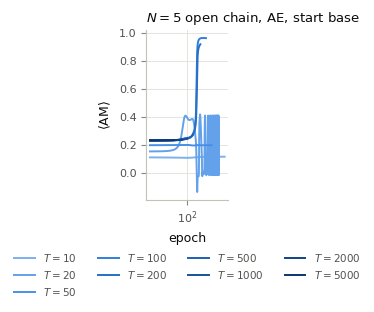

wrote chain_N5/cost_vs_epoch_AM2_base.pdf


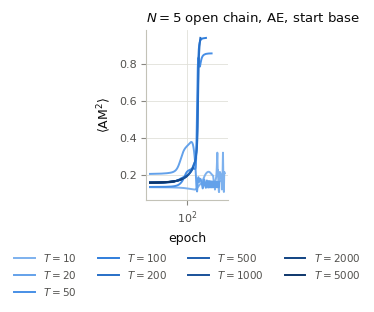

In [3]:
for cost in COSTS:
    geom_tag, init = GEOMETRY, INIT
    runs = RUNS[cost]
    dest = str(Path(FIGS) / geom_tag)
    TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    suffix = f"{cost}_{init}"
    colors = F.ramp_colors(len(TL))
    best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

    # -- 1. measured order parameter vs epoch, one curve per T ----------- #
    colors = F.ramp_colors(len(TL))
    fig, ax = plt.subplots(figsize=(3.2, 3.0), layout="none")
    fig.subplots_adjust(left=0.20, right=0.98, bottom=0.20, top=0.87)
    for c, T in zip(colors, TL):
        y = curve(runs, "AE", T)
        ax.plot(np.arange(1, len(y) + 1), y, color=c, label=f"$T={T}$")
    ax.set_xscale("log")
    F.finish(ax, "epoch", COST_LABEL[cost],
             f"{pretty(geom_tag)}, AE, start {init}", legend=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4)
    save(fig, os.path.join(dest, f"cost_vs_epoch_{suffix}.pdf"))




## 2. Order parameter versus accumulated evolution time

The horizontal axis follows the existing study convention `N_epoch * T`; ordinary AE actually uses two full sweeps per epoch.


wrote chain_N5/physical_time_AM_base.pdf


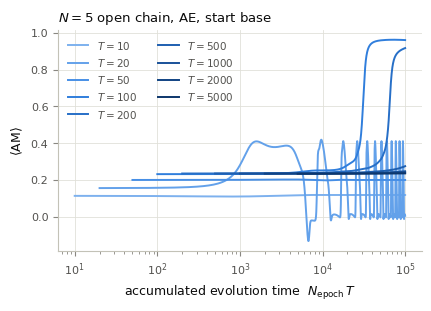

wrote chain_N5/physical_time_AM2_base.pdf


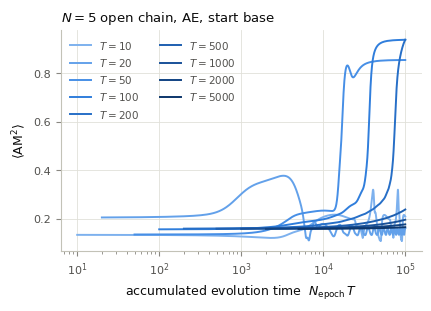

In [4]:
for cost in COSTS:
    geom_tag, init = GEOMETRY, INIT
    runs = RUNS[cost]
    dest = str(Path(FIGS) / geom_tag)
    TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    suffix = f"{cost}_{init}"
    colors = F.ramp_colors(len(TL))
    best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

    # -- 2. same data against accumulated physical evolution time -------- #
    fig, ax = plt.subplots(figsize=(4.2, 3.0))
    for c, T in zip(colors, TL):
        y = curve(runs, "AE", T)
        ax.plot(np.arange(1, len(y) + 1) * T, y, color=c, label=f"$T={T}$")
    ax.set_xscale("log")
    F.finish(ax, "accumulated evolution time  $N_{\\mathrm{epoch}}\\,T$",
             COST_LABEL[cost],
             f"{pretty(geom_tag)}, AE, start {init}", ncol=2)
    save(fig, os.path.join(dest, f"physical_time_{suffix}.pdf"))




## 2b. Order parameter versus epoch and accumulated evolution time

Combine figures 1 and 2 in two panels, separately for AFM and AFM². Each pair shares its y-axis and a legend below both panels. Distinct colors identify the same evolution times across both panels and both observables. The stored measurements are unchanged; accumulated time follows the existing convention `N_epoch * T`.


wrote chain_N5/cost_vs_epoch_time_AM_base.pdf


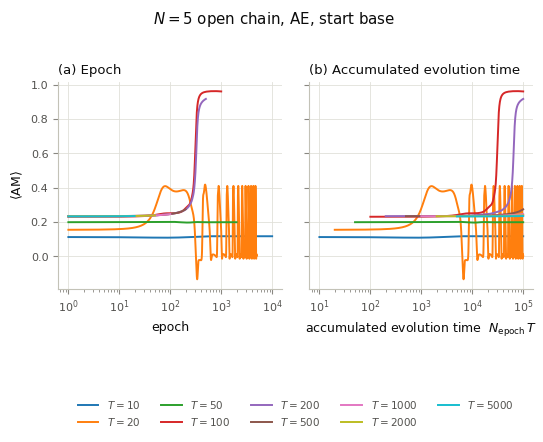

wrote chain_N5/cost_vs_epoch_time_AM2_base.pdf


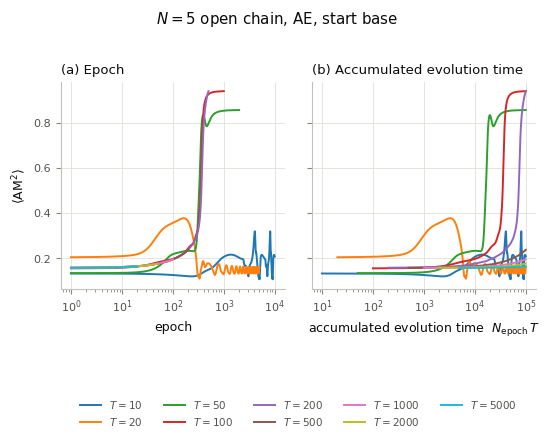

In [5]:
# Keep fixed margins during both PDF and PNG export.
# Fixed T-to-color mapping shared by both panels and both observables.
time_colors = dict(zip(TL_DEFAULT, [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf",
]))
with plt.rc_context({"figure.constrained_layout.use": False}):
    for cost in COSTS:
        runs = RUNS[cost]
        TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
        colors = [time_colors[T] for T in TL]
        fig, axes = plt.subplots(1, 2, figsize=(5.4, 4.5), sharey=True, layout="none")
        fig.subplots_adjust(left=0.10, right=0.98, bottom=0.34, top=0.80, wspace=0.12)
        for color, T in zip(colors, TL):
            y = curve(runs, "AE", T)
            epochs = np.arange(1, len(y) + 1)
            axes[0].plot(epochs, y, color=color, label=f"$T={T}$")
            axes[1].plot(epochs * T, y, color=color, label=f"$T={T}$")
        for ax in axes:
            ax.set_xscale("log")
        F.finish(axes[0], "epoch", COST_LABEL[cost],
                 "(a) Epoch", legend=False)
        F.finish(axes[1], r"accumulated evolution time  $N_{\mathrm{epoch}}\,T$",
                 title="(b) Accumulated evolution time", legend=False)
        fig.suptitle(f"{pretty(GEOMETRY)}, AE, start {INIT}", y=0.96)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center",
                   bbox_to_anchor=(0.54, 0.01), ncol=5)
        save(fig, str(Path(FIGS) / GEOMETRY / f"cost_vs_epoch_time_{cost}_{INIT}.pdf"))


## 3. Parameter trajectories over the phase diagram

Keep the existing selection: T=20, 100, 1000 plus the T with the largest observed order parameter. The existing ED truncation and axis limits are retained to reproduce the original figures.


### 3a. AFM — AM


wrote chain_N5/trajectory_T20_AM_base.pdf


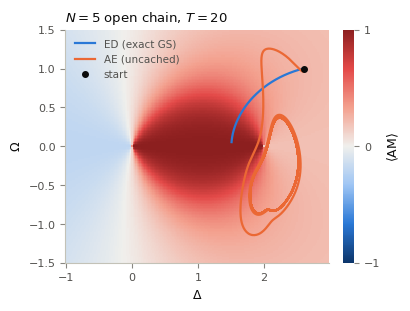

wrote chain_N5/trajectory_T100_AM_base.pdf


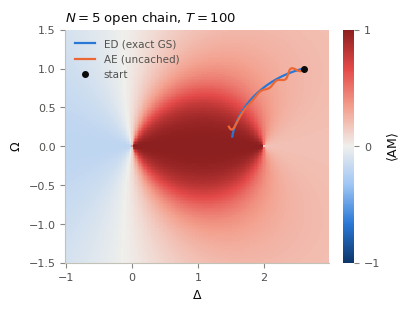

wrote chain_N5/trajectory_T1000_AM_base.pdf


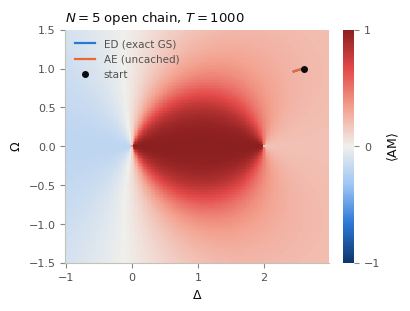

In [6]:
cost = "AM"
geom_tag, init = GEOMETRY, INIT
runs = RUNS[cost]
dest = str(Path(FIGS) / geom_tag)
TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
suffix = f"{cost}_{init}"
colors = F.ramp_colors(len(TL))
best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

# -- 3. trajectories over the phase diagram -------------------------- #
ph = phase_for(geom_tag)
# a short T, a long T, and whichever T the adiabatic estimator did best at
best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))
traj_T = sorted({t for t in (20, 100, 1000) if t in TL} | {best_T})
for T in traj_T:
    fig, ax = plt.subplots(figsize=(4.0, 3.0))
    if ph is not None:
        pcm = ax.pcolormesh(ph["Delta_list"], ph["Omega_list"],
                            ph["AM" if cost == "AM" else "AM2"],
                            cmap=F.CMAP_DIVERGING if cost == "AM"
                            else F.CMAP_SEQUENTIAL,
                            vmin=-1 if cost == "AM" else 0, vmax=1,
                            shading="auto", rasterized=True)
        cb = fig.colorbar(pcm, ax=ax)
        cb.set_label(COST_LABEL[cost])
        cb.set_ticks([-1, 0, 1] if cost == "AM" else [0, 0.5, 1])
        cb.outline.set_visible(False)
    n = len(curve(runs, "AE", T))
    ed = ed_slice(runs, n)
    if ed is not None:
        ax.plot(ed["Delta"], ed["Omega"], color=F.METHOD_COLOR["ED"],
                lw=1.6, label=F.METHOD_LABEL["ED"])
    for m in [x for x in METHODS if x != "ED"]:
        d = runs.get(m, {}).get(f"{T:g}")
        if d is None:
            continue
        ax.plot(d["Delta"], d["Omega"], color=F.METHOD_COLOR[m], lw=1.6,
                ls=F.METHOD_STYLE[m], label=F.METHOD_LABEL[m])
    d0 = runs["AE"][f"{T:g}"]
    ax.plot(d0["Delta"][0], d0["Omega"][0], "o", color=F.INK, ms=4,
            label="start")
    ax.grid(False)
    ax.set_ylim(-1.5, 1.5)
    F.finish(ax, r"$\Delta$", r"$\Omega$",
             f"{pretty(geom_tag)}, $T={T}$")
    save(fig, os.path.join(dest, f"trajectory_T{T}_{suffix}.pdf"))




### 3b. AFM² — AM²


wrote chain_N5/trajectory_T20_AM2_base.pdf


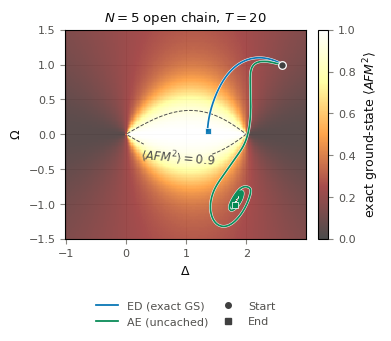

wrote chain_N5/trajectory_T50_AM2_base.pdf


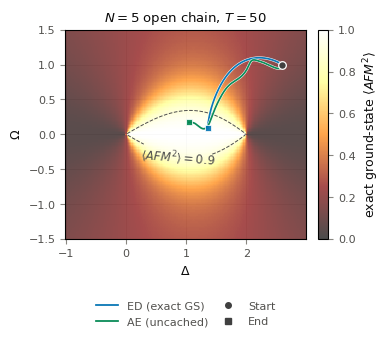

wrote chain_N5/trajectory_T100_AM2_base.pdf


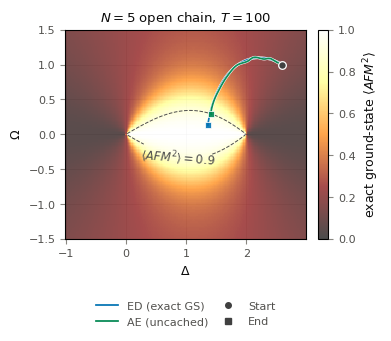

wrote chain_N5/trajectory_T200_AM2_base.pdf


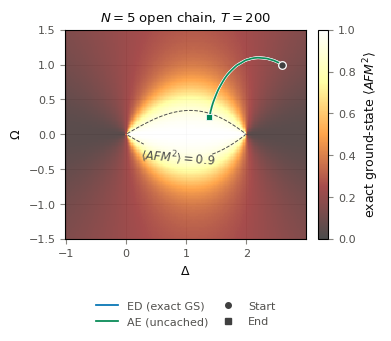

In [7]:
# Figure 3b only: appearance matched to the multiple-shot cell62 reference.
# Keep these settings local so figure 3a and the other figure families do not change.
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects

cost = "AM2"
geom_tag, init = GEOMETRY, INIT
runs = RUNS[cost]
dest = str(Path(FIGS) / geom_tag)
TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
suffix = f"{cost}_{init}"
best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))
traj_T = sorted({t for t in (20, 50, 100) if t in TL} | {best_T})
ph = phase_for(geom_tag)

# Blue and green are taken directly from the reference's blue/purple/green palette.
trajectory_colors = {"ED": "#0072B2", "AE": "#008751"}
path_width, outline_width = 1.25, 0.7
with plt.rc_context({"axes.edgecolor": "black", "axes.linewidth": 0.8}):
    for T in traj_T:
        fig, ax = plt.subplots(figsize=(3.8, 3.3))
        if ph is not None:
            pcm = ax.pcolormesh(
                ph["Delta_list"], ph["Omega_list"], ph["AM2"],
                cmap="afmhot", alpha=0.7, vmin=0, vmax=1,
                shading="auto", rasterized=True,
            )
            # Quantitative contour, not a thermodynamic phase-boundary claim.
            if np.nanmin(ph["AM2"]) < 0.9 < np.nanmax(ph["AM2"]):
                contour = ax.contour(
                    ph["Delta_list"], ph["Omega_list"], ph["AM2"],
                    levels=[0.9], colors="0.3", linewidths=0.7,
                    linestyles="--", zorder=2,
                )
                ax.clabel(contour, fmt={0.9: r"$\langle AFM^2\rangle=0.9$"},
                          fontsize=8.5, inline=True)
            cb = fig.colorbar(pcm, ax=ax)
            cb.set_label(r"exact ground-state $\langle AFM^2\rangle$")
            cb.set_ticks(np.linspace(0, 1, 6))
            cb.outline.set_visible(True)
            cb.outline.set_edgecolor("black")

        n = len(curve(runs, "AE", T))
        ed = ed_slice(runs, n)
        plotted_methods = []
        for method, d in (("ED", ed), ("AE", runs["AE"][f"{T:g}"])):
            if d is None:
                continue
            color = trajectory_colors[method]
            line, = ax.plot(d["Delta"], d["Omega"], color=color,
                            lw=path_width, alpha=0.95, zorder=3)
            line.set_path_effects([
                path_effects.Stroke(linewidth=path_width + outline_width,
                                    foreground="white"),
                path_effects.Normal(),
            ])
            ax.scatter(d["Delta"][-1], d["Omega"][-1], marker="s", s=22,
                       facecolors=color, edgecolors="white", linewidths=0.6,
                       alpha=0.9, zorder=4)
            plotted_methods.append(method)
        d0 = runs["AE"][f"{T:g}"]
        ax.plot(d0["Delta"][0], d0["Omega"][0], "o", color="0.25",
                ms=5.5, mec="white", mew=0.9, zorder=5)

        # Preserve the existing scientific view: the reference's Delta <= 2.25
        # zoom would hide this study's initial Delta=2.6.
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel(r"$\Delta$")
        ax.set_ylabel(r"$\Omega$")
        ax.set_title(f"{pretty(geom_tag)}, $T={T}$", loc="center")
        ax.grid(True, color="0.65", alpha=0.22)
        for spine in ax.spines.values():
            spine.set_visible(True)
        handles = [Line2D([], [], color=trajectory_colors[m], lw=path_width,
                          label=F.METHOD_LABEL[m]) for m in plotted_methods]
        handles.extend([
            Line2D([], [], color="0.25", ls="none", marker="o", ms=4, label="Start"),
            Line2D([], [], color="0.25", ls="none", marker="s", ms=4, label="End"),
        ])
        ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.25),
                  ncol=2, fontsize=8, frameon=True, framealpha=0.9,
                  edgecolor="none", columnspacing=0.8)
        save(fig, os.path.join(dest, f"trajectory_T{T}_{suffix}.pdf"))


### 3c. Combined smooth/stiff trajectories on the AFM² phase diagram

Regenerate `figs/trajectory_combo_chain_N5.pdf` and its PNG with the reference layout. The equilibrium background, colorbar, and 0.9 contour show **⟨AFM²⟩**, with scale [0,1]. The overlaid paths are **AM$^2$-trained** high-learning-rate (`lr=0.1`) runs, i.e. the same observable as the background.

Blue/magenta distinguish smooth/stiff; dashed/solid distinguish the two evolution times in `SHORT_T, LONG_T` (currently $T=20$ / $T=100$, run for 5000 / 1000 epochs -- `N_epoch = 10^5/T`). Run after setup; `SAVE_FIGURES` and `AFM_NOTEBOOK_FIGURE_ROOT` apply here too. All plotting code is included below.


wrote trajectory_combo_chain_N5.pdf


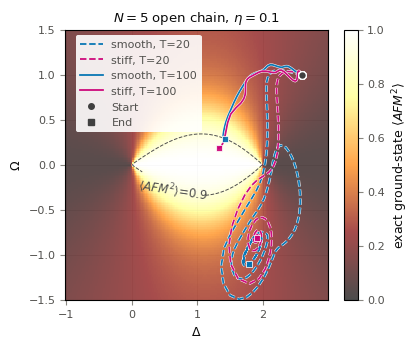

In [8]:
def plot_combined_trajectories():
    """AM2 equilibrium background with the original trained trajectories."""
    from matplotlib.lines import Line2D
    import matplotlib.patheffects as path_effects

    geom, outdir = GEOMETRY, FIGS
    SHORT_T, LONG_T, LR = 20, 100, 0.1
    endpoint=200

    def load_combo_input(category, filename):
        # Match the original script: paper copies first, main-study fallback.
        for base in (PAPER / "data", PAPER.parent / "data"):
            path = base / category / filename
            if path.is_file():
                return np.load(path, allow_pickle=True)
        raise FileNotFoundError(f"Missing {category}/{filename}")

    cost = 'AM2'  # user wants the combo trajectories trained with AFM^2, not AM
    # The requested background is AM2, independently of the training objective.
    background_cost = 'AM2'
    label = r'$\langle AFM^2\rangle$'
    ph = load_combo_input("phase", f"phase_{geom}.npz")
    if ph is None:
        raise FileNotFoundError(f'Missing phase diagram for {geom}')
    paths = {}
    for schedule in ('smooth', 'stiff'):
        for T in (SHORT_T, LONG_T):
            loaded = load_combo_input("train", f"{geom}_{cost}_AE_{schedule}_T{T}_hilr.npz")
            if loaded is None:
                raise FileNotFoundError(f'Missing {geom}/{cost}/{schedule}/T={T}')
            with loaded as d:
                paths[schedule, T] = {k: d[k].copy() for k in ('Omega', 'Delta', 'y')}
            if not all(np.isfinite(v).all() for v in paths[schedule, T].values()):
                raise ValueError(f'Nonfinite trajectory: {schedule}, T={T}')

    colors = {'smooth': '#0072B2', 'stiff': '#CC0077'}
    with plt.rc_context({'axes.edgecolor': 'black', 'axes.linewidth': 0.8,
                         'figure.constrained_layout.use': False}):
        fig, ax = plt.subplots(figsize=(4., 3.7))
        # The external six-entry legend must not squeeze the phase axes.
        fig.subplots_adjust(left=.14, right=.96, bottom=.17, top=.90)
        with ph:
            mesh = ax.pcolormesh(ph['Delta_list'], ph['Omega_list'], ph[background_cost],
                                 cmap='afmhot', alpha=0.7,
                                 vmin=0, vmax=1,
                                 shading='auto', rasterized=True)
            if np.nanmin(ph[background_cost]) < 0.9 < np.nanmax(ph[background_cost]):
                contour = ax.contour(ph['Delta_list'], ph['Omega_list'], ph[background_cost],
                                     levels=[0.9], colors='0.3', linewidths=0.7,
                                     linestyles='--', zorder=2)
                ax.clabel(contour, fmt={0.9: label + '=0.9'}, fontsize=8.5, inline=True)
        cb = fig.colorbar(mesh, ax=ax)
        cb.set_label('exact ground-state ' + label)
        cb.set_ticks(np.linspace(0, 1, 6))
        cb.outline.set_edgecolor('black')

        handles = []
        # Draw both long paths last so shorter-time paths do not obscure them.
        for T in (SHORT_T, LONG_T):
            for schedule in ('smooth', 'stiff'):
                d = paths[schedule, T]
                color = colors[schedule]
                ls = '--' if T == SHORT_T else '-'
                line, = ax.plot(d['Delta'][0:endpoint], d['Omega'][0:endpoint], color=color, ls=ls,
                                lw=1.25, alpha=0.95, zorder=3 if T == SHORT_T else 4)
                line.set_path_effects([
                    path_effects.Stroke(linewidth=1.95, foreground='white'),
                    path_effects.Normal(),
                ])
                ax.scatter(d['Delta'][endpoint], d['Omega'][endpoint], marker='s', s=22,
                           facecolors=color, edgecolors='white', linewidths=.6,
                           alpha=.9, zorder=5)
                handles.append(Line2D([], [], color=color, ls=ls, lw=1.25,
                                      label=f'{schedule}, T={T}'))
                ax.plot(d['Delta'][0], d['Omega'][0], 'o', color='0.25',
                        ms=5.5, mec='white', mew=.9, zorder=6)
        handles += [Line2D([], [], color='0.25', ls='none', marker=marker, ms=4, label=text)
                    for marker, text in (('o', 'Start'), ('s', 'End'))]
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(.28, 1),
                  ncol=1, fontsize=8, frameon=True, framealpha=.9,
                  edgecolor='none', columnspacing=.8)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel(r'$\Delta$')
        ax.set_ylabel(r'$\Omega$')
        ax.set_title(f'{pretty(geom)}, $\\eta={LR:g}$', loc='center')
        ax.grid(True, color='0.65', alpha=.22)
        for spine in ax.spines.values():
            spine.set_visible(True)
        out = os.path.join(outdir, f'trajectory_combo_{geom}.pdf')
        save(fig, out)

plot_combined_trajectories()


### 3d. Adiabatic modulation schedule

The actual physical $(\Delta(t), \Omega(t))$ path swept during one
adiabatic evolution, from `afmqep.schedules.make_modulation_funcs`,
overlaid on the same AFM$^2$ phase diagram as 3b/3c. This path's *shape*
does not depend on $T$ (the schedule is a function of $t/T$ only). Each
phase only moves one of $\Delta$ or $\Omega$ at a time, so smooth and stiff
trace the *exact same* polyline through $(\Delta,\Omega)$ -- the raised-cosine
vs piecewise-linear ramp only changes the *speed* along that path, not its
route (drawn as a thick dotted line under a thin solid one to show this).

Two points are marked:

- **adiabatic start** ($\Delta=-1$, $\Omega=0$): the trivial, fully
  Rabi-symmetric Hamiltonian the sweep begins from -- hardcoded in
  `make_modulation_funcs`, not a trained or tested parameter.
- **target parameter** ($\Omega_0,\Delta_0$)=(1.0, 2.6): the point whose
  ground state the sweep is meant to prepare, i.e. the parameter this
  study actually wants -- the same start used by every trajectory in 3b/3c.


wrote chain_N5/modulation_schedule.pdf


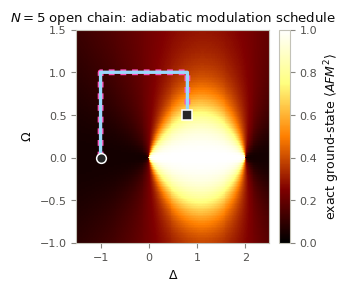

In [40]:
import sys
sys.path.insert(0, str(PAPER.parent / "code"))
from afmqep.schedules import SMOOTH, STIFF

AE_START = (-1.0, 0.0)      # (Delta, Omega) the modulation sweep begins from
TARGET = (0.5, 0.8)               # (Omega_0, Delta_0) -- the tested/target parameter
tau = np.linspace(0, 1, 400)
T_demo = 1.0                  # path shape is independent of T; only rescales t

fig, ax = plt.subplots(figsize=(3.3, 2.8))
# The regular data/phase/phase_chain_N5.npz starts at Delta=-1, exactly where
# the adiabatic sweep starts -- no margin to see the start point sit inside
# the diagram. Recomputed with code/phase_diagram.py --Delta-range -2.5,3
# (same Omega range/resolution) into a separate directory so the original
# phase file/figures are untouched.
with np.load(PAPER / "data" / "phase_wide" / f"phase_{GEOMETRY}.npz", allow_pickle=True) as _d:
    ph = {key: _d[key].copy() for key in _d.files}
pcm = ax.pcolormesh(ph["Delta_list"], ph["Omega_list"], ph["AM2"],
                    cmap="afmhot", alpha=1., vmin=0, vmax=1,
                    shading="auto", rasterized=True)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label(r"exact ground-state $\langle AFM^2\rangle$")
cb.set_ticks(np.linspace(0, 1, 6))

# Each phase only moves one of (Delta, Omega) at a time, so the ramp shape
# (raised cosine vs piecewise-linear) only changes the *speed* along the
# path, not its *route* -- smooth and stiff trace the identical polyline.
# Drawn as a thick dotted line under a thinner solid one so the exact
# overlap is visible rather than looking like a missing series.
schedule_styles = {"stiff": dict(color="#FF50B6", lw=4.2, ls=(0, (1, 1)), zorder=2),
                   "smooth": dict(color="#9AD7FB", lw=2.4, ls="-", zorder=3)}
for name, (func_Omega, func_Delta, _) in (("stiff", STIFF), ("smooth", SMOOTH)):
    t = tau * T_demo
    Omega_t = np.asarray(func_Omega(t, TARGET[0], T_demo))
    Delta_t = np.asarray(func_Delta(t, TARGET[1], T_demo))
    ax.plot(Delta_t, Omega_t, label=f"{name} ramp", **schedule_styles[name])

ax.plot(*AE_START, "o", color="0.15", ms=7, mec="white", mew=1.1,
        zorder=5, label="adiabatic start")
ax.plot(TARGET[1], TARGET[0], "s", color="0.15", ms=7, mec="white", mew=1.1,
        zorder=5, label="target parameter")

ax.set_ylim(-1, 1.5)
ax.set_xlim(-1.5, 2.5)
ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"$\Omega$")
ax.set_title(f"{pretty(GEOMETRY)}: adiabatic modulation schedule")
#ax.legend(loc="upper left", fontsize=8, frameon=True, framealpha=.9, edgecolor="none", ncol=2, bbox_to_anchor=(0., -0.2))
ax.grid(True, color="0.65", alpha=.22)
save(fig, os.path.join(FIGS, GEOMETRY, "modulation_schedule.pdf"))


## 4. Order parameter at fixed time budgets

Only measurements whose budget has been reached are included; missing budgets are not extrapolated.


wrote chain_N5/time_budget_AM_base.pdf


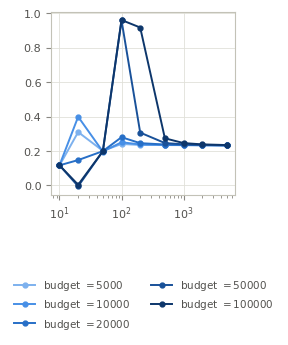

wrote chain_N5/time_budget_AM2_base.pdf


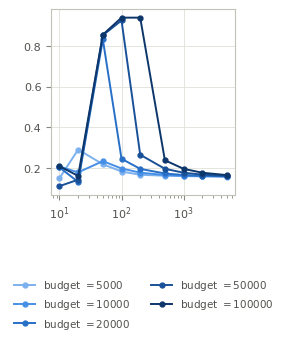

In [10]:
for cost in COSTS:
    geom_tag, init = GEOMETRY, INIT
    runs = RUNS[cost]
    dest = str(Path(FIGS) / geom_tag)
    TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    suffix = f"{cost}_{init}"
    colors = F.ramp_colors(len(TL))
    best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

    # -- 4. final value vs T at several total time budgets --------------- #
    TBL = [5000, 10000, 20000, 50000, 100000]
    fig, ax = plt.subplots(figsize=(2.2, 2.2))
    for c, TB in zip(F.ramp_colors(len(TBL)), TBL):
        xs, ys = [], []
        for T in TL:
            y = curve(runs, "AE", T)
            idx = int(TB / T) - 1
            if 0 <= idx < len(y):
                xs.append(T)
                ys.append(y[idx])
        ax.plot(xs, ys, "o-", color=c, label=f"budget $={TB:g}$")
    ax.set_xscale("log")
    #F.finish(ax, "$T$ per epoch", COST_LABEL[cost],
    #         f"{pretty(geom_tag)}, AE, start {init}")
    fig.legend( bbox_to_anchor=(1.2, -0.2), ncol=2)
    save(fig, os.path.join(dest, f"time_budget_{suffix}.pdf"))




## 5. Time-budget heat map

Show the measured order parameter at the selected (T, epoch) pairs, with the original fixed-budget boundary.


wrote chain_N5/time_budget_heat_AM_base.pdf


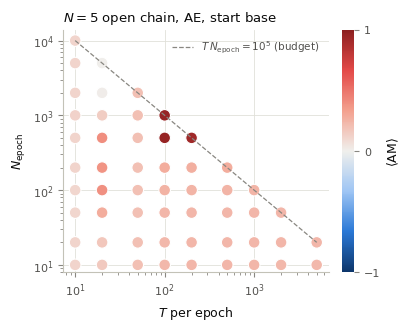

wrote chain_N5/time_budget_heat_AM2_base.pdf


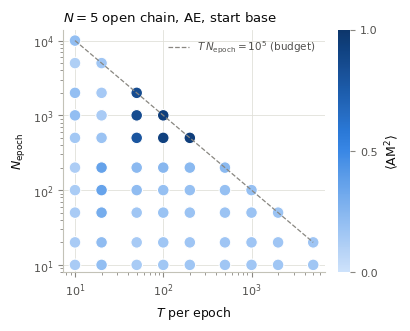

In [11]:
for cost in COSTS:
    geom_tag, init = GEOMETRY, INIT
    runs = RUNS[cost]
    dest = str(Path(FIGS) / geom_tag)
    TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    suffix = f"{cost}_{init}"
    colors = F.ramp_colors(len(TL))
    best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

    # -- 5. (T, N_epoch) heat map ---------------------------------------- #
    NeL = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
    X, Y, C = [], [], []
    for T in TL:
        y = curve(runs, "AE", T)
        for Ne in NeL:
            if Ne <= len(y):
                X.append(T)
                Y.append(Ne)
                C.append(y[Ne - 1])
    fig, ax = plt.subplots(figsize=(4.0, 3.2))
    sc = ax.scatter(X, Y, c=C, cmap=F.CMAP_DIVERGING if cost == "AM"
                    else F.CMAP_SEQUENTIAL,
                    vmin=-1 if cost == "AM" else 0, vmax=1, s=70,
                    edgecolors=F.SURFACE, linewidths=0.8)
    tt = np.array([min(TL), max(TL)], dtype=float)
    ax.plot(tt, 1e5 / tt, ls="--", lw=0.9, color=F.MUTED,
            label=r"$T\,N_{\mathrm{epoch}}=10^5$ (budget)")
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label(COST_LABEL[cost])
    cb.set_ticks([-1, 0, 1] if cost == "AM" else [0, 0.5, 1])
    cb.outline.set_visible(False)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(8, 1.4e4)
    F.finish(ax, "$T$ per epoch", "$N_{\\mathrm{epoch}}$",
             f"{pretty(geom_tag)}, AE, start {init}", legend=True)
    save(fig, os.path.join(dest, f"time_budget_heat_{suffix}.pdf"))




## 6. Exact-QEP versus ordinary-AE comparisons

Compare the stored ED and AE curves over the observed epochs. Cached AE is not plotted.


wrote chain_N5/methods_AM_base.pdf


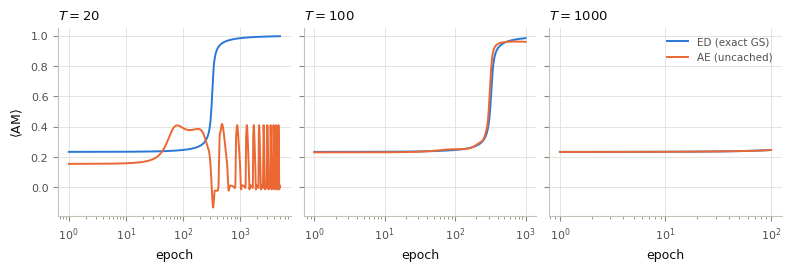

wrote chain_N5/methods_AM2_base.pdf


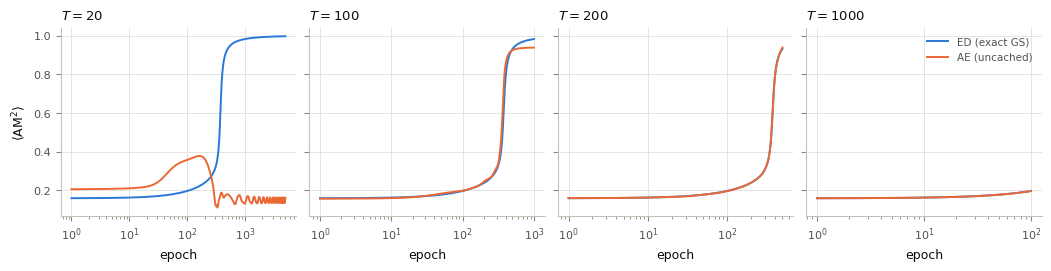

In [12]:
for cost in COSTS:
    geom_tag, init = GEOMETRY, INIT
    runs = RUNS[cost]
    dest = str(Path(FIGS) / geom_tag)
    TL = [T for T in TL_DEFAULT if curve(runs, "AE", T) is not None]
    suffix = f"{cost}_{init}"
    colors = F.ramp_colors(len(TL))
    best_T = max(TL, key=lambda t: float(np.max(curve(runs, "AE", t))))

    # -- 6. ED and ordinary AE side by side ---------------------------- #
    Tsel = sorted({t for t in (20, 100, 1000) if t in TL} | {best_T})
    if Tsel:
        fig, axes = plt.subplots(1, len(Tsel), figsize=(2.6 * len(Tsel), 2.6),
                                 sharey=True)
        axes = np.atleast_1d(axes)
        for ax, T in zip(axes, Tsel):
            n = len(curve(runs, "AE", T))
            ed = ed_slice(runs, n)
            if ed is not None:
                ax.plot(np.arange(1, len(ed["y"]) + 1), ed["y"],
                        color=F.METHOD_COLOR["ED"], label=F.METHOD_LABEL["ED"])
            for m in [x for x in METHODS if x != "ED"]:
                y = curve(runs, m, T)
                if y is not None:
                    ax.plot(np.arange(1, len(y) + 1), y, color=F.METHOD_COLOR[m],
                            ls=F.METHOD_STYLE[m], label=F.METHOD_LABEL[m])
            ax.set_xscale("log")
            F.finish(ax, "epoch", COST_LABEL[cost] if ax is axes[0] else None,
                     f"$T={T}$", legend=(ax is axes[-1]))
        save(fig, os.path.join(dest, f"methods_{suffix}.pdf"))
